In [1]:
import numpy as np
import pandas as pd
import matplotlib.pylab as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

In [2]:
df = pd.read_csv("./Credit_Card_Dataset.csv")

## 1. Understanding the dataset

In [4]:
df.shape

(8950, 18)

In [3]:
df.columns

Index(['CUST_ID', 'BALANCE', 'BALANCE_FREQUENCY', 'PURCHASES',
       'ONEOFF_PURCHASES', 'INSTALLMENTS_PURCHASES', 'CASH_ADVANCE',
       'PURCHASES_FREQUENCY', 'ONEOFF_PURCHASES_FREQUENCY',
       'PURCHASES_INSTALLMENTS_FREQUENCY', 'CASH_ADVANCE_FREQUENCY',
       'CASH_ADVANCE_TRX', 'PURCHASES_TRX', 'CREDIT_LIMIT', 'PAYMENTS',
       'MINIMUM_PAYMENTS', 'PRC_FULL_PAYMENT', 'TENURE'],
      dtype='str')

In [16]:
df.head()

,CUST_ID,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
0,C10001,40.900749,0.818182,95.40,0.00,95.4,0.000000,0.166667,0.000000,0.083333,0.000000,0,2,1000.0,201.802084,139.509787,0.000000,12
1,C10002,3202.467416,0.909091,0.00,0.00,0.0,6442.945483,0.000000,0.000000,0.000000,0.250000,4,0,7000.0,4103.032597,1072.340217,0.222222,12
2,C10003,2495.148862,1.000000,773.17,773.17,0.0,0.000000,1.000000,1.000000,0.000000,0.000000,0,12,7500.0,622.066742,627.284787,0.000000,12
3,C10004,1666.670542,0.636364,1499.00,1499.00,0.0,205.788017,0.083333,0.083333,0.000000,0.083333,1,1,7500.0,0.000000,NaN,0.000000,12
4,C10005,817.714335,1.000000,16.00,16.00,0.0,0.000000,0.083333,0.083333,0.000000,0.000000,0,1,1200.0,678.334763,244.791237,0.000000,12


In [5]:
df.duplicated().sum()

np.int64(0)

In [6]:
df.isnull().sum()

CUST_ID                               0
BALANCE                               0
BALANCE_FREQUENCY                     0
PURCHASES                             0
ONEOFF_PURCHASES                      0
INSTALLMENTS_PURCHASES                0
CASH_ADVANCE                          0
PURCHASES_FREQUENCY                   0
ONEOFF_PURCHASES_FREQUENCY            0
PURCHASES_INSTALLMENTS_FREQUENCY      0
CASH_ADVANCE_FREQUENCY                0
CASH_ADVANCE_TRX                      0
PURCHASES_TRX                         0
CREDIT_LIMIT                          1
PAYMENTS                              0
MINIMUM_PAYMENTS                    313
PRC_FULL_PAYMENT                      0
TENURE                                0
dtype: int64

In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 8950 entries, 0 to 8949
Data columns (total 18 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   CUST_ID                           8950 non-null   str    
 1   BALANCE                           8950 non-null   float64
 2   BALANCE_FREQUENCY                 8950 non-null   float64
 3   PURCHASES                         8950 non-null   float64
 4   ONEOFF_PURCHASES                  8950 non-null   float64
 5   INSTALLMENTS_PURCHASES            8950 non-null   float64
 6   CASH_ADVANCE                      8950 non-null   float64
 7   PURCHASES_FREQUENCY               8950 non-null   float64
 8   ONEOFF_PURCHASES_FREQUENCY        8950 non-null   float64
 9   PURCHASES_INSTALLMENTS_FREQUENCY  8950 non-null   float64
 10  CASH_ADVANCE_FREQUENCY            8950 non-null   float64
 11  CASH_ADVANCE_TRX                  8950 non-null   int64  
 12  PURCHASES_TRX    

In [8]:
df.describe()

,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
count,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8949.000000,8950.000000,8637.000000,8950.000000,8950.000000
mean,1564.474828,0.877271,1003.204834,592.437371,411.067645,978.871112,0.490351,0.202458,0.364437,0.135144,3.248827,14.709832,4494.449450,1733.143852,864.206542,0.153715,11.517318
std,2081.531879,0.236904,2136.634782,1659.887917,904.338115,2097.163877,0.401371,0.298336,0.397448,0.200121,6.824647,24.857649,3638.815725,2895.063757,2372.446607,0.292499,1.338331
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,50.000000,0.000000,0.019163,0.000000,6.000000
25%,128.281915,0.888889,39.635000,0.000000,0.000000,0.000000,0.083333,0.000000,0.000000,0.000000,0.000000,1.000000,1600.000000,383.276166,169.123707,0.000000,12.000000
50%,873.385231,1.000000,361.280000,38.000000,89.000000,0.000000,0.500000,0.083333,0.166667,0.000000,0.000000,7.000000,3000.000000,856.901546,312.343947,0.000000,12.000000
75%,2054.140036,1.000000,1110.130000,577.405000,468.637500,1113.821139,0.916667,0.300000,0.750000,0.222222,4.000000,17.000000,6500.000000,1901.134317,825.485459,0.142857,12.000000
max,19043.138560,1.000000,49039.570000,40761.250000,22500.000000,47137.211760,1.000000,1.000000,1.000000,1.500000,123.000000,358.000000,30000.000000,50721.483360,76406.207520,1.000000,12.000000


## 2. Handling the missing values

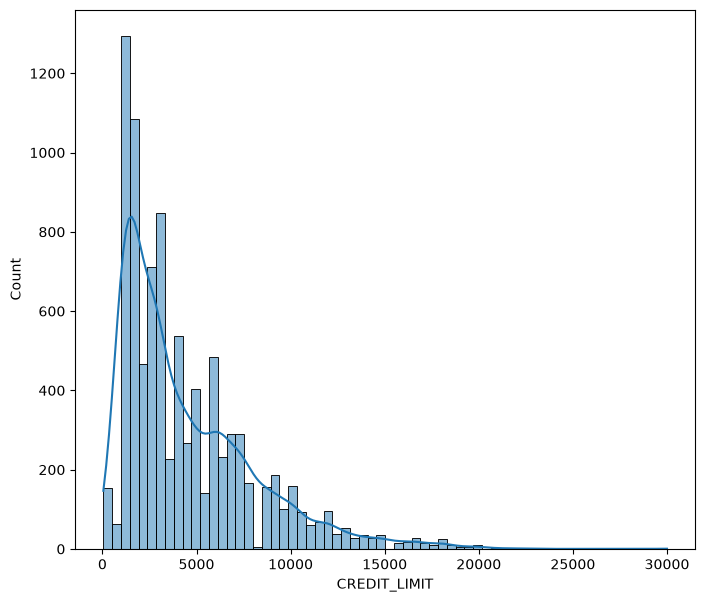

In [11]:
plt.figure(figsize=(8,7))
sns.histplot(df["CREDIT_LIMIT"], kde=True)
plt.show()

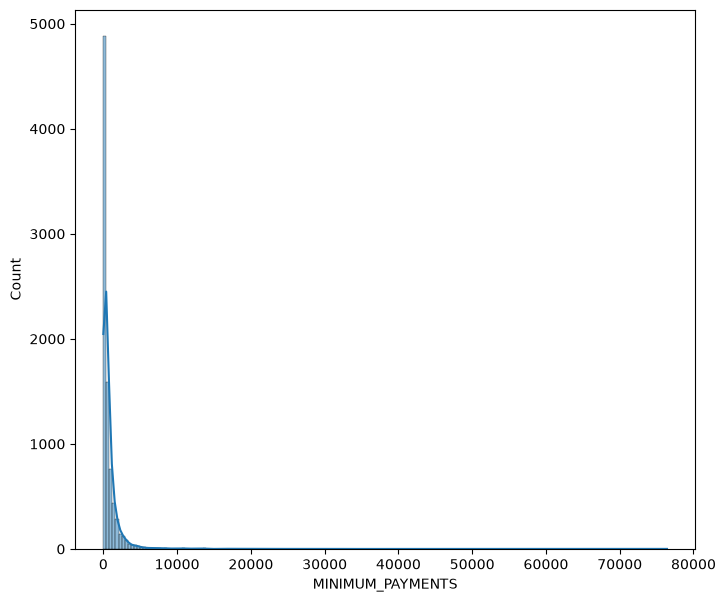

In [14]:
plt.figure(figsize=(8,7))
sns.histplot(df["MINIMUM_PAYMENTS"], kde=True)
plt.show()

Distribution is skewed so choosing median imputation

In [15]:
dfcopy = df.copy()

In [17]:
dfcopy.fillna({
    "CREDIT_LIMIT": dfcopy["CREDIT_LIMIT"].median(),
    "MINIMUM_PAYMENTS": dfcopy["MINIMUM_PAYMENTS"].median(),
}, inplace=True)

dfcopy.isnull().sum()

CUST_ID                             0
BALANCE                             0
BALANCE_FREQUENCY                   0
PURCHASES                           0
ONEOFF_PURCHASES                    0
INSTALLMENTS_PURCHASES              0
CASH_ADVANCE                        0
PURCHASES_FREQUENCY                 0
ONEOFF_PURCHASES_FREQUENCY          0
PURCHASES_INSTALLMENTS_FREQUENCY    0
CASH_ADVANCE_FREQUENCY              0
CASH_ADVANCE_TRX                    0
PURCHASES_TRX                       0
CREDIT_LIMIT                        0
PAYMENTS                            0
MINIMUM_PAYMENTS                    0
PRC_FULL_PAYMENT                    0
TENURE                              0
dtype: int64

## 3. Scaling the Data

In [ ]:
dfcopy.drop(columns=["CUST_ID"], inplace=True)

dfcopy.columns

Index(['BALANCE', 'BALANCE_FREQUENCY', 'PURCHASES', 'ONEOFF_PURCHASES',
       'INSTALLMENTS_PURCHASES', 'CASH_ADVANCE', 'PURCHASES_FREQUENCY',
       'ONEOFF_PURCHASES_FREQUENCY', 'PURCHASES_INSTALLMENTS_FREQUENCY',
       'CASH_ADVANCE_FREQUENCY', 'CASH_ADVANCE_TRX', 'PURCHASES_TRX',
       'CREDIT_LIMIT', 'PAYMENTS', 'MINIMUM_PAYMENTS', 'PRC_FULL_PAYMENT',
       'TENURE'],
      dtype='str')

In [20]:
scaler = StandardScaler()

scaled_data = scaler.fit_transform(dfcopy)

scaled_df = pd.DataFrame(scaled_data, columns=dfcopy.columns)

scaled_df.head()

,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
0,-0.731989,-0.249434,-0.424900,-0.356934,-0.349079,-0.466786,-0.806490,-0.678661,-0.707313,-0.675349,-0.476070,-0.511333,-0.960378,-0.528979,-0.302400,-0.525551,0.36068
1,0.786961,0.134325,-0.469552,-0.356934,-0.454576,2.605605,-1.221758,-0.678661,-0.916995,0.573963,0.110074,-0.591796,0.688678,0.818642,0.097500,0.234227,0.36068
2,0.447135,0.518084,-0.107668,0.108889,-0.454576,-0.466786,1.269843,2.673451,-0.916995,-0.675349,-0.476070,-0.109020,0.826100,-0.383805,-0.093293,-0.525551,0.36068
3,0.049099,-1.016953,0.232058,0.546189,-0.454576,-0.368653,-1.014125,-0.399319,-0.916995,-0.258913,-0.329534,-0.551565,0.826100,-0.598688,-0.228307,-0.525551,0.36068
4,-0.358775,0.518084,-0.462063,-0.347294,-0.454576,-0.466786,-1.014125,-0.399319,-0.916995,-0.675349,-0.476070,-0.551565,-0.905410,-0.364368,-0.257266,-0.525551,0.36068


In [21]:
print("Mean of each column: \n ", scaled_df.mean())

print("Standard deviation of each column: \n", scaled_df.std())

Mean of each column: 
  BALANCE                             8.891708e-17
BALANCE_FREQUENCY                   2.286439e-16
PURCHASES                           0.000000e+00
ONEOFF_PURCHASES                    3.175610e-17
INSTALLMENTS_PURCHASES              2.540488e-17
CASH_ADVANCE                        1.016195e-16
PURCHASES_FREQUENCY                -1.841854e-16
ONEOFF_PURCHASES_FREQUENCY         -8.891708e-17
PURCHASES_INSTALLMENTS_FREQUENCY    4.604634e-17
CASH_ADVANCE_FREQUENCY              5.557317e-17
CASH_ADVANCE_TRX                   -2.540488e-17
PURCHASES_TRX                      -2.540488e-17
CREDIT_LIMIT                        1.270244e-16
PAYMENTS                           -3.810732e-17
MINIMUM_PAYMENTS                    5.716098e-17
PRC_FULL_PAYMENT                    0.000000e+00
TENURE                              2.794537e-16
dtype: float64
Standard deviation of each column: 
 BALANCE                             1.000056
BALANCE_FREQUENCY                   1.000056
P

## 4. Using the elbow scaling to find the K

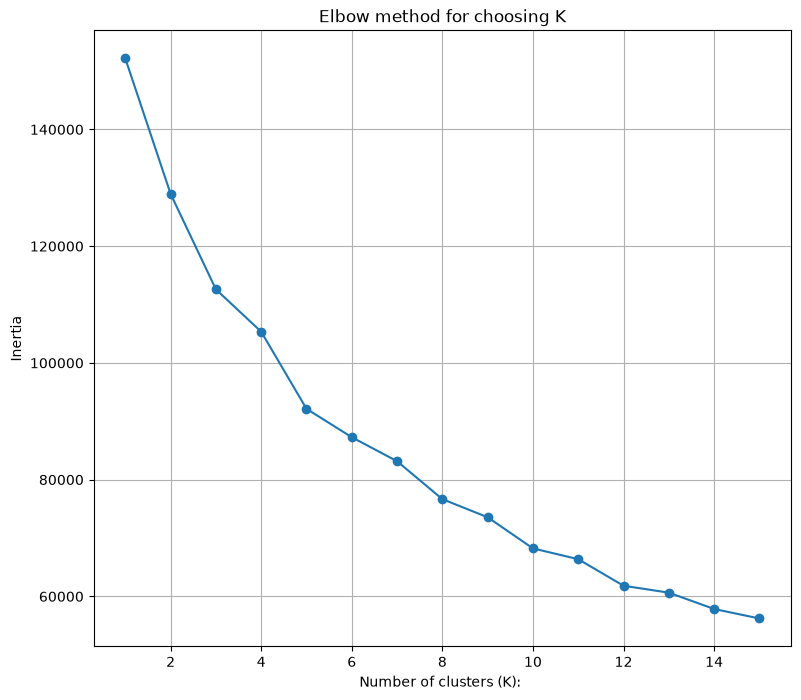

In [22]:
inertia_values = []

for k in range(1, 16):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(scaled_df)
    inertia_values.append(kmeans.inertia_)

plt.figure(figsize=(9,8))
plt.plot(range(1, 16), inertia_values, marker="o")
plt.xlabel("Number of clusters (K): ")
plt.ylabel("Inertia")
plt.title("Elbow method for choosing K")
plt.grid(True)
plt.show()

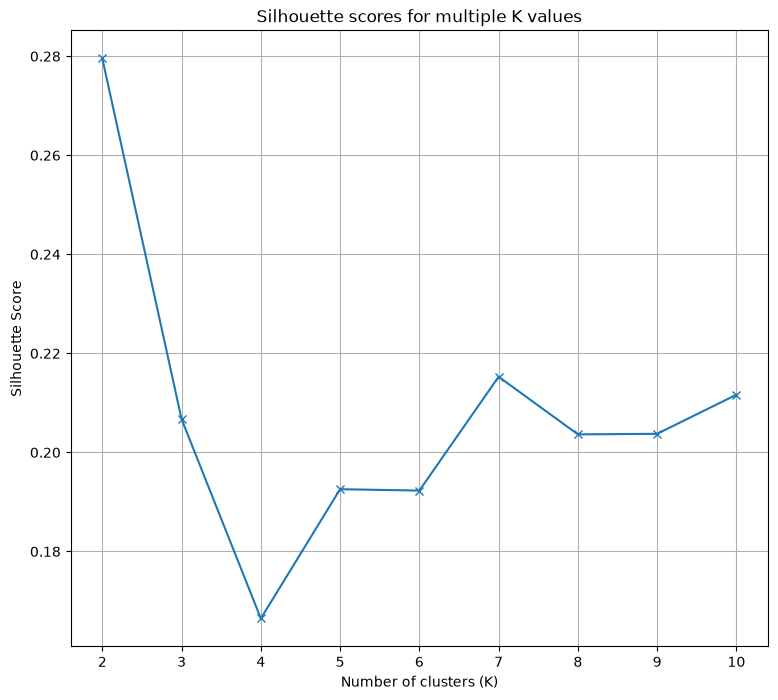

In [24]:
silhouette_scores = []

for k in range(2, 11): 
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(scaled_df)
    score = silhouette_score(scaled_df, kmeans.labels_)
    silhouette_scores.append(score)

plt.figure(figsize=(9,8))
plt.plot(range(2, 11), silhouette_scores, marker="x")
plt.xlabel("Number of clusters (K)")
plt.ylabel("Silhouette Score")
plt.title("Silhouette scores for multiple K values")
plt.grid(True)
plt.show()

One needs to look at both the clustering graph and the silhouette graph and then decide the K number according the logic of the dataset

Here 4 is the best choice because the financial dataset generally demands more than 2 groups of people. But will try all the 3 values 2, 4 and 5

In [25]:
kmeans = KMeans(n_clusters=4, random_state=42)
kmeans.fit(scaled_df)

df["Cluster"] = kmeans.labels_

df.head()

,CUST_ID,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE,Cluster
0,C10001,40.900749,0.818182,95.40,0.00,95.4,0.000000,0.166667,0.000000,0.083333,0.000000,0,2,1000.0,201.802084,139.509787,0.000000,12,3
1,C10002,3202.467416,0.909091,0.00,0.00,0.0,6442.945483,0.000000,0.000000,0.000000,0.250000,4,0,7000.0,4103.032597,1072.340217,0.222222,12,0
2,C10003,2495.148862,1.000000,773.17,773.17,0.0,0.000000,1.000000,1.000000,0.000000,0.000000,0,12,7500.0,622.066742,627.284787,0.000000,12,2
3,C10004,1666.670542,0.636364,1499.00,1499.00,0.0,205.788017,0.083333,0.083333,0.000000,0.083333,1,1,7500.0,0.000000,NaN,0.000000,12,3
4,C10005,817.714335,1.000000,16.00,16.00,0.0,0.000000,0.083333,0.083333,0.000000,0.000000,0,1,1200.0,678.334763,244.791237,0.000000,12,3


In [26]:
df["Cluster"].value_counts()

Cluster
3    3368
2    3118
1    1487
0     977
Name: count, dtype: int64

## 5. PCA visualization

Before clustering

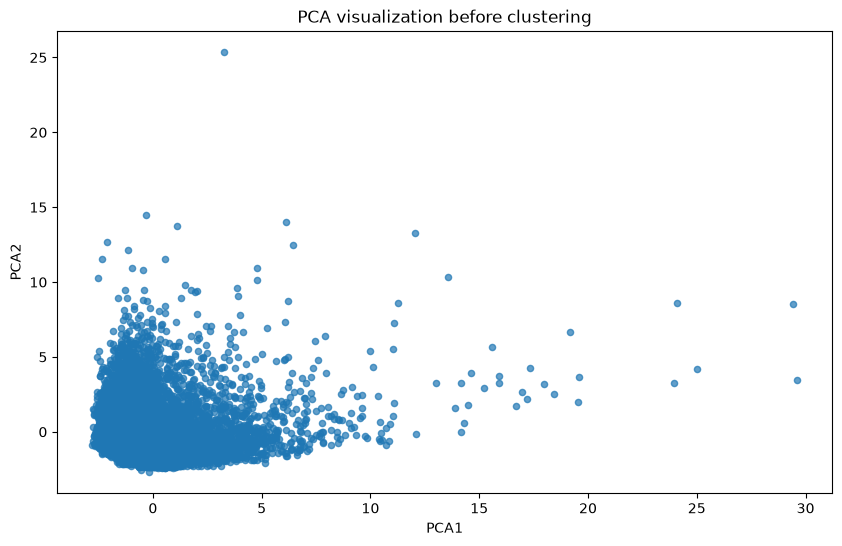

In [27]:
pca = PCA(n_components=2)
pca_components = pca.fit_transform(scaled_df)

plt.figure(figsize=(10,6))
plt.scatter(pca_components[:, 0], pca_components[:, 1], s=20, alpha=0.7)
plt.title("PCA visualization before clustering")
plt.xlabel("PCA1")
plt.ylabel("PCA2")
plt.show()

After clustering

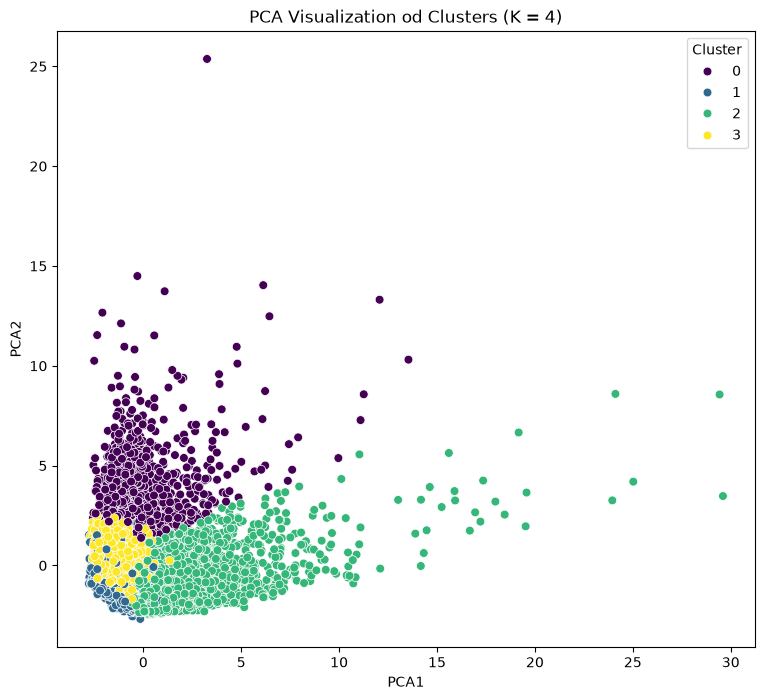

In [29]:
pca = PCA(n_components=2)
pca_components= pca.fit_transform(scaled_df)

pca_df = pd.DataFrame(data=pca_components, columns=["PCA1", "PCA2"])
pca_df["Cluster"] = df["Cluster"]

plt.figure(figsize=(9,8))
sns.scatterplot(x="PCA1", y="PCA2", hue="Cluster", palette="viridis", data=pca_df ,s=40)
plt.title("PCA Visualization od Clusters (K = 4)")
plt.show()

## 6. Cluster Interpretation

In [32]:
cluster_profile = df.drop(columns=["CUST_ID"]).groupby("Cluster").mean()

cluster_profile

,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
Cluster,,,,,,,,,,,,,,,,,
0,5010.394668,0.966663,716.017789,450.235875,265.885977,5065.974690,0.327150,0.160632,0.218675,0.508502,15.770727,10.345957,8208.653578,4173.817878,2230.240661,0.040025,11.416581
1,108.430006,0.412096,350.247868,190.521089,160.197189,299.482324,0.320591,0.072760,0.234912,0.035072,0.730330,4.812374,3632.537386,1036.853064,148.364006,0.253704,11.217888
2,1253.817942,0.974758,2182.022178,1241.768493,940.517248,234.564524,0.928413,0.390217,0.748106,0.041717,0.807569,32.727389,5121.987288,2148.583305,783.470382,0.282970,11.729314
3,1495.324927,0.966467,283.482824,210.004454,73.794186,782.285268,0.207097,0.098032,0.108717,0.157514,2.988420,3.665380,3216.349960,947.961448,814.482174,0.022886,11.482482


Comparing the balance of the clusters

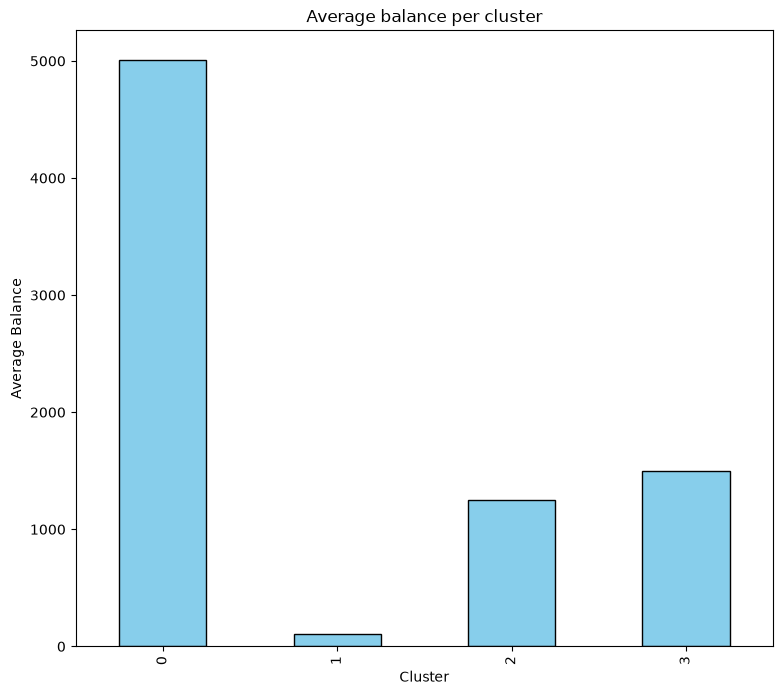

In [31]:
plt.figure(figsize=(9,8))
cluster_profile["BALANCE"].plot(kind="bar", color='skyblue', edgecolor="#010101")
plt.title("Average balance per cluster")
plt.xlabel("Cluster")
plt.ylabel("Average Balance")
plt.show()

Comparing the purchases of clusters

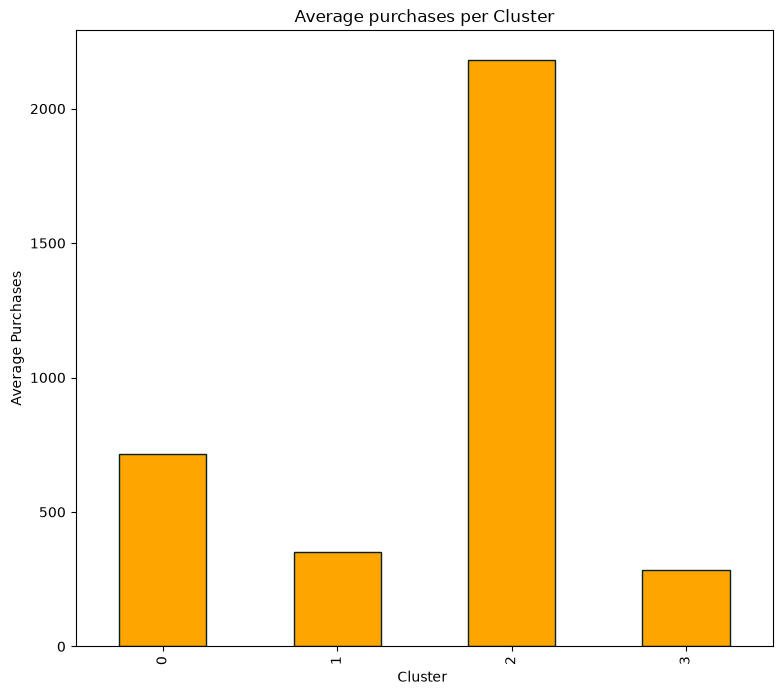

In [33]:
plt.figure(figsize=(9,8))
cluster_profile["PURCHASES"].plot(kind="bar", color="orange", edgecolor="#022020")
plt.title("Average purchases per Cluster")
plt.xlabel("Cluster ")
plt.ylabel("Average Purchases")
plt.show()

Compare cash advance of cluster

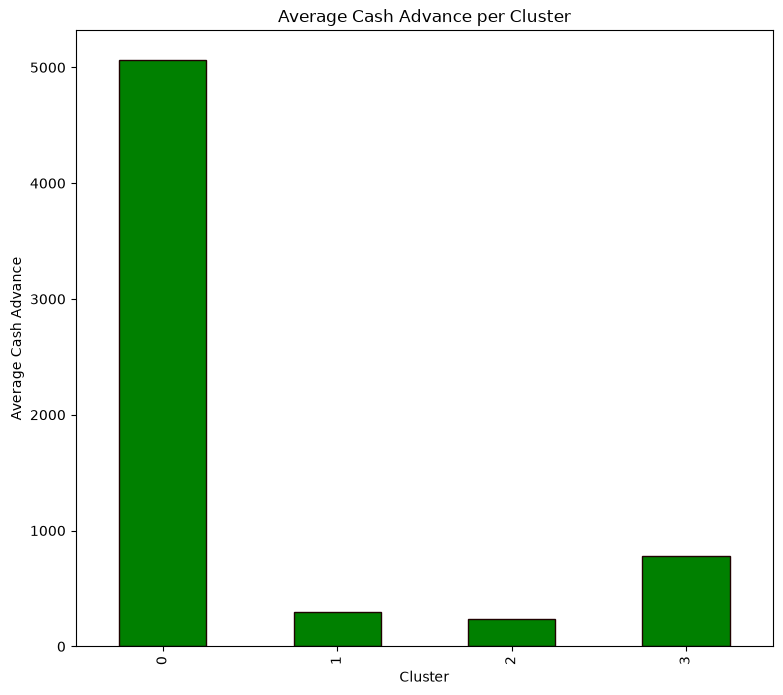

In [35]:
plt.figure(figsize=(9,8))
cluster_profile["CASH_ADVANCE"].plot(kind="bar", color="green", edgecolor="#200202")
plt.title("Average Cash Advance per Cluster")
plt.xlabel('Cluster')
plt.ylabel("Average Cash Advance")
plt.show()

Compare credit limit for clusters

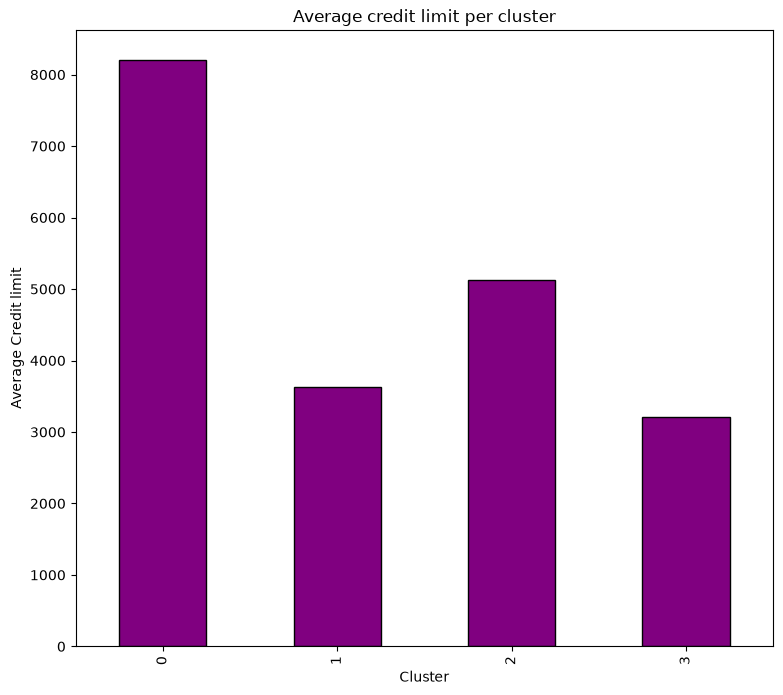

In [36]:
plt.figure(figsize=(9,8))
cluster_profile["CREDIT_LIMIT"].plot(kind="bar", color="purple", edgecolor="#010101")
plt.title("Average credit limit per cluster")
plt.xlabel("Cluster")
plt.ylabel("Average Credit limit")
plt.show()

Comparison of full payment ratio

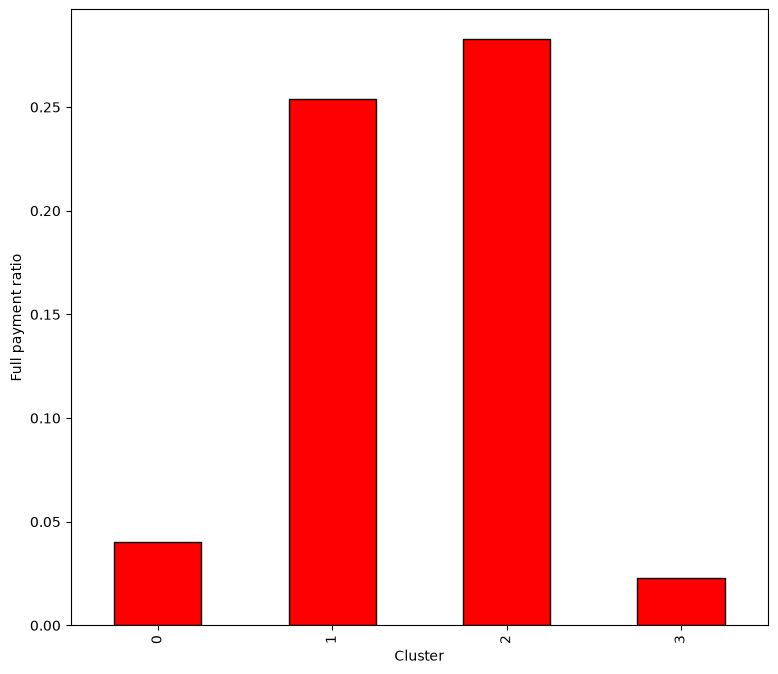

In [37]:
plt.figure(figsize=(9,8))
cluster_profile["PRC_FULL_PAYMENT"].plot(kind="bar", color="red", edgecolor="#030303")
plt.xlabel("Cluster")
plt.ylabel("Full payment ratio")
plt.show()

Radial chart for visualization and comparison of clusters

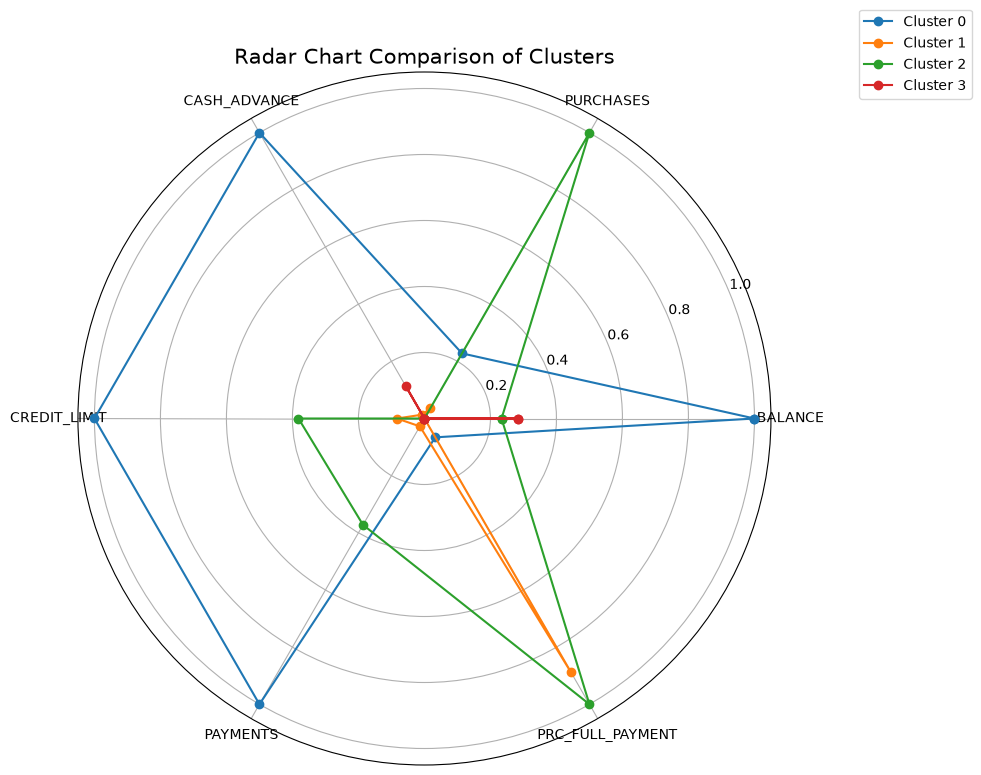

In [40]:
features = ['BALANCE', 'PURCHASES', 'CASH_ADVANCE', 'CREDIT_LIMIT', 'PAYMENTS', 'PRC_FULL_PAYMENT']
    
data = cluster_profile[features]

data_norm = (data - data.min()) / (data.max() - data.min())

num_vars = len(features)

angles = np.linspace(0, 2 * np.pi, num_vars, endpoint=False).tolist()
angles += angles[:1]

plt.figure(figsize=(9, 9))

for i in range(len(data_norm)):
    values = data_norm.iloc[i].tolist()
    values += values[:1]

    plt.polar(angles, values, marker='o', label=f'Cluster {i}')

plt.xticks(angles[:-1], features)
plt.title("Radar Chart Comparison of Clusters", size=15)
plt.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1))
plt.show()